# Retail Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [2]:
df=pd.read_csv("../Data/store_sales.csv")

In [3]:
df.head()

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10


In [4]:
df.tail()

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
4995,4996,44,Female,Accessories,Sunglasses,172.64,Winter,Card,3.6,20,5
4996,4997,59,Male,Groceries,Beverages,54.00,Spring,Cash on Delivery,3.8,14,2
4997,4998,41,Female,Accessories,Handbag,159.33,Autumn,Card,4.3,26,8
4998,4999,63,Female,Womens Clothing,Skirt,173.82,Autumn,Card,4.8,26,8
4999,5000,41,Female,Footwear,Sandals,55.39,Autumn,Cash on Delivery,4.1,19,7


In [5]:
df.shape

(5000, 11)

In [6]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Category', 'ItemPurchased', 'Amount',
       'Season', 'PaymentMethod', 'ItemRating', 'DiscountApplied(%)',
       'PreviousPurchases'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   str    
 3   Category            5000 non-null   str    
 4   ItemPurchased       5000 non-null   str    
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   str    
 7   PaymentMethod       5000 non-null   str    
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 429.8 KB


In [8]:
df.describe()

,CustomerID,Age,Amount,ItemRating,DiscountApplied(%),PreviousPurchases
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.224800,285.090522,3.784160,14.983600,5.008800
std,1443.520003,14.564995,551.454382,0.681796,5.988063,2.194285
min,1.000000,20.000000,5.080000,1.100000,0.000000,0.000000
25%,1250.750000,33.000000,70.547500,3.300000,11.000000,3.000000
50%,2500.500000,45.000000,122.485000,3.800000,15.000000,5.000000
75%,3750.250000,58.000000,184.535000,4.300000,19.000000,6.000000
max,5000.000000,70.000000,2997.940000,5.000000,36.000000,13.000000


In [9]:
df.isnull().sum()

CustomerID            0
Age                   0
Gender                0
Category              0
ItemPurchased         0
Amount                0
Season                0
PaymentMethod         0
ItemRating            0
DiscountApplied(%)    0
PreviousPurchases     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

CustomerID            5000
Age                     51
Gender                   2
Category                 9
ItemPurchased           30
Amount                4565
Season                   4
PaymentMethod            2
ItemRating              39
DiscountApplied(%)      32
PreviousPurchases       14
dtype: int64

In [12]:
df.sample(10)

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
4212,4213,26,Female,Groceries,Cooking Oil,59.78,Autumn,Card,4.3,15,5
4396,4397,36,Female,Beauty,Perfume,28.51,Spring,Card,2.9,16,3
4489,4490,50,Male,Mens Clothing,T-Shirt,37.53,Winter,Card,3.5,8,4
1085,1086,29,Female,Womens Clothing,Top,45.21,Spring,Card,3.9,25,10
4109,4110,39,Female,Womens Clothing,Dress,154.17,Autumn,Card,4.0,23,9
1287,1288,36,Male,Footwear,Formal Shoes,114.22,Autumn,Card,3.9,22,6
2457,2458,37,Male,Sports,Dumbbells,163.30,Autumn,Card,3.6,12,6
324,325,38,Female,Sports,Football,240.47,Autumn,Card,3.4,8,4
2682,2683,69,Female,Footwear,Sneakers,228.38,Autumn,Card,4.0,14,7
3257,3258,34,Male,Footwear,Formal Shoes,113.73,Autumn,Card,3.6,21,8


In [13]:
df["Gender"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [14]:
df["Category"].unique()

<StringArray>
[    'Accessories',   'Mens Clothing',          'Sports',            'Home',
       'Groceries',     'Electronics',          'Beauty',        'Footwear',
 'Womens Clothing']
Length: 9, dtype: str

### Purchase Amount Outlier Analysis

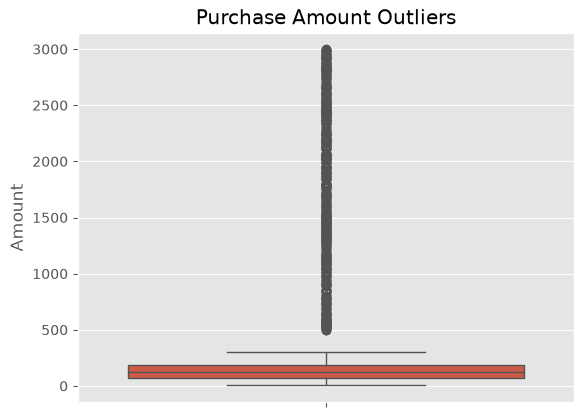

In [21]:
plt.Figure(figsize=(8,5))
sns.boxplot(y=df["Amount"])
plt.title("Purchase Amount Outliers")

plt.savefig("../Images/purchase_outliers.png",
            dpi=400,
            bbox_inches="tight")

plt.show()

**Observation**

- Most purchase amounts are concentrated within a relatively low range.
- The boxplot reveals several high-value outliers above the upper whisker.
- The purchase amount distribution is positively skewed, indicating that a small number of customers spend significantly more than the majority.

### Distribution of Numerical Features

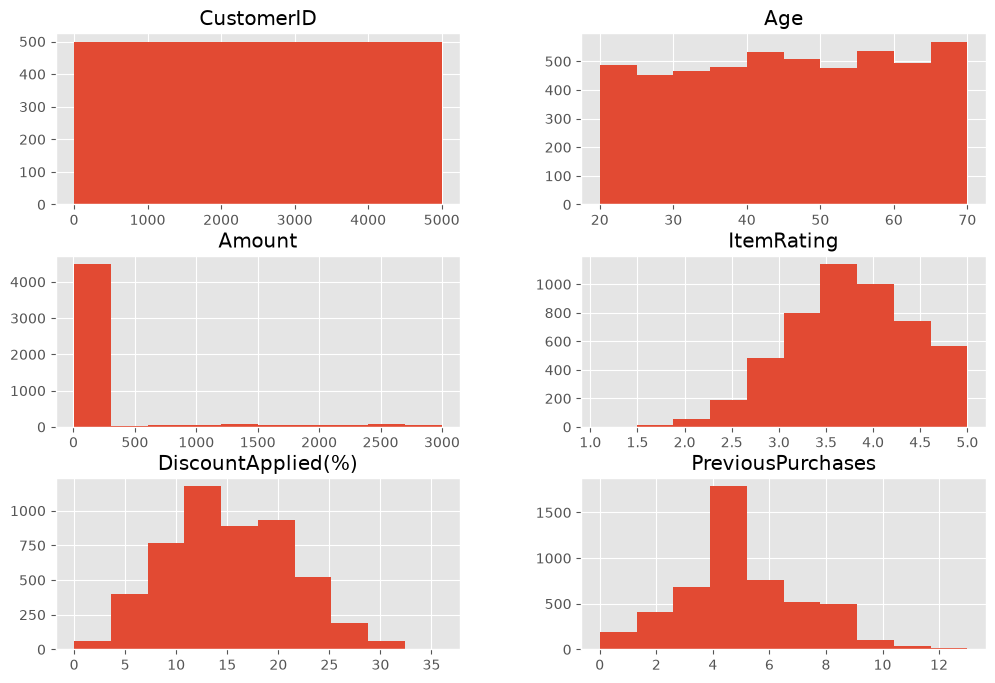

In [17]:
df.hist(figsize=(12,8))

plt.savefig("../Images/Numerical_Features.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation**

- Customer ages are fairly evenly distributed between 20 and 70 years.
- Purchase Amount is right-skewed due to a few very high-value purchases.
- Most Item Ratings fall between 3 and 4.5, indicating generally positive customer feedback.
- Most customers have made around 4–6 previous purchases.
- Discount percentages are mainly concentrated between 10% and 20%.

### Gender Distribution

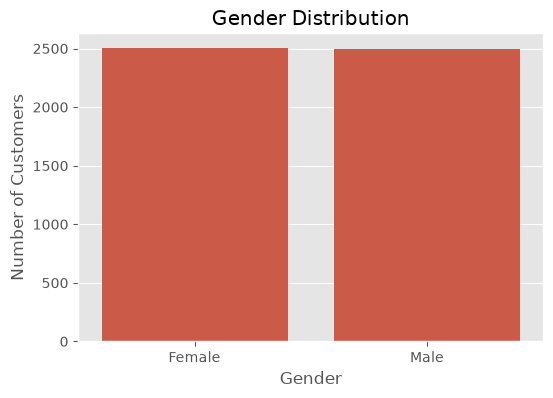

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.savefig("../Images/Gender_Distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Observation**

- The dataset contains an almost equal number of male and female customers.
- No significant gender imbalance is observed.
- The balanced distribution makes the dataset suitable for comparing purchasing behaviour across genders.

### Customer Age Distribution

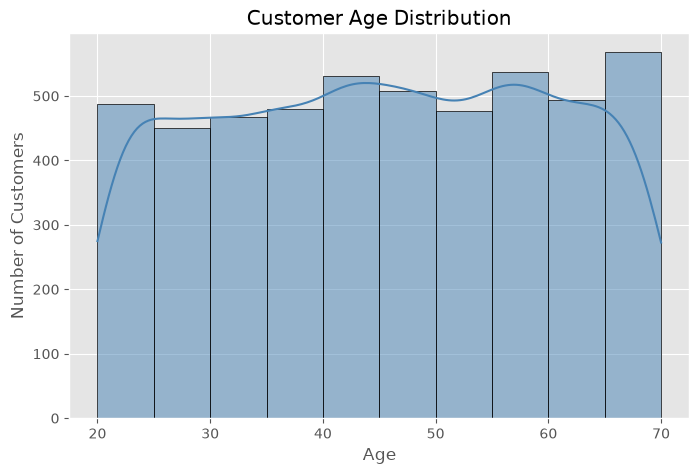

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Age", bins=10 , color="steelblue", edgecolor="black", kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.savefig("../Images/Age_Distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Observation**

- Customer ages are distributed fairly evenly between 20 and 70 years.
- The highest customer concentration is observed around the 40–60 age group.
- No strong left or right skewness is present, indicating a balanced age distribution.
- The KDE curve suggests there are no unusual age clusters or extreme outliers.
- The business serves customers across a wide range of age groups rather than focusing on a single age segment.

### Product Category Distribution

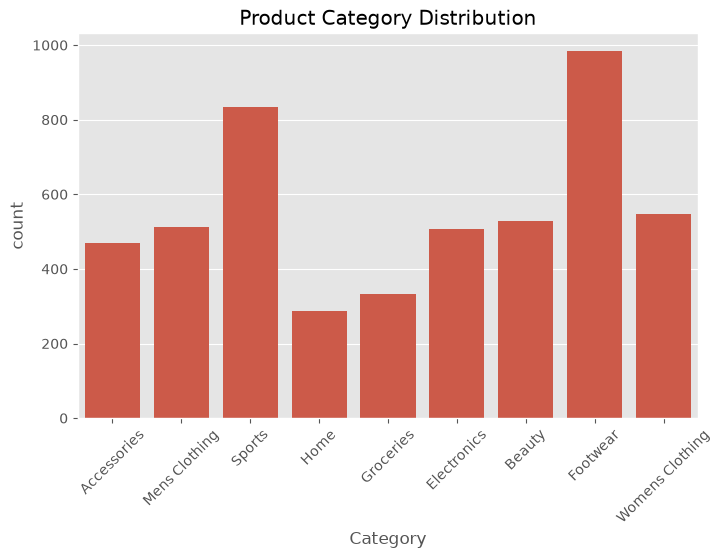

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Category")

plt.title("Product Category Distribution")
plt.xticks(rotation=45)

plt.savefig("../Images/Category_Distribution.png",
            dpi=400,
            bbox_inches="tight")

plt.show()

**Observation**

- Footwear has the highest number of purchases among all product categories.
- Sports products also show strong customer demand.
- Home and Groceries have the lowest purchase counts.
- Customer purchases are concentrated in fashion and sports-related categories.

### Average Purchase Amount by Category

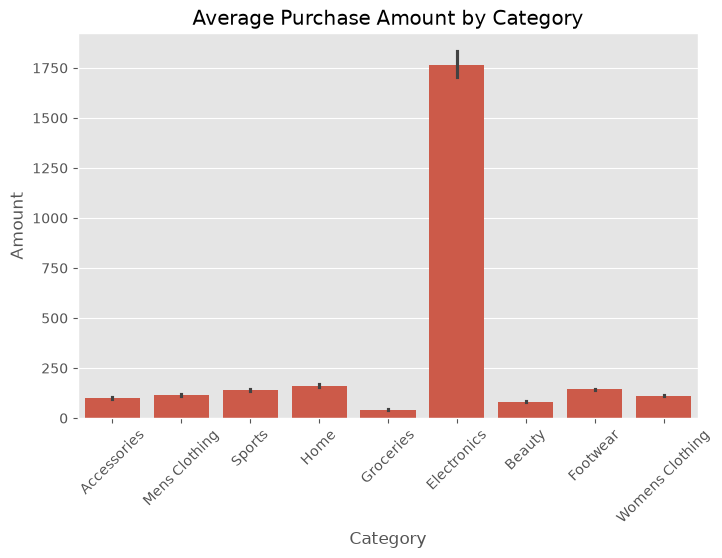

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(data=df , x="Category" , y="Amount")

plt.title("Average Purchase Amount by Category")
plt.xticks(rotation=45)

plt.savefig("../Images/Average_Purchase_Category.png",
            dpi=400,
            bbox_inches="tight")

plt.show()

**Observation**

- Electronics have the highest average purchase amount by a significant margin.
- Home and Footwear categories also have relatively high average purchase values.
- Grocery products have the lowest average purchase amount.
- Customer spending varies considerably across product categories.

### Top 10 Best-Selling Products

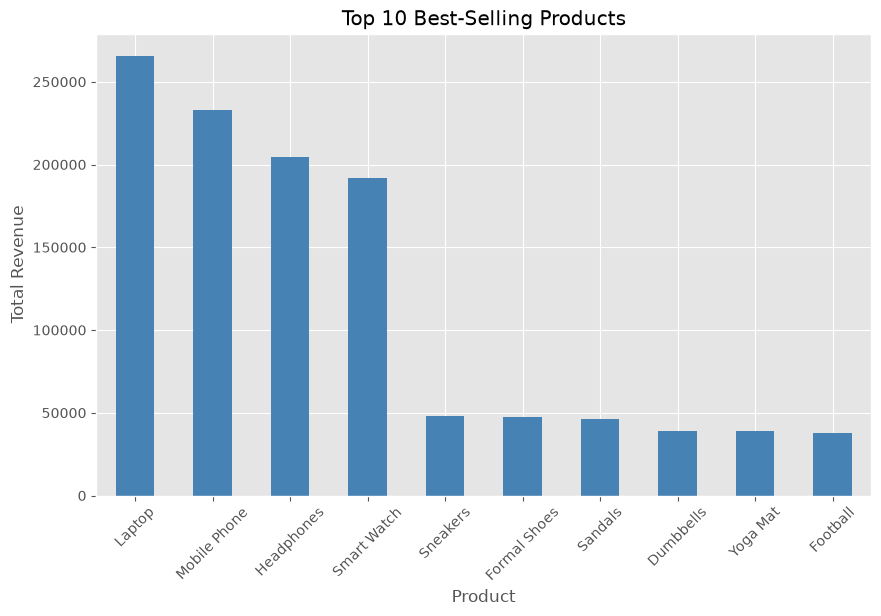

In [24]:
top_products =(
    df.groupby("ItemPurchased")["Amount"].sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_products.plot(kind="bar", color="steelblue")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.savefig("../Images/Top_10_Products.png",
            dpi=400,
            bbox_inches="tight")

plt.show()

**Observation**

- Laptop generates the highest total revenue among all products.
- Mobile Phone, Headphones and Smart Watch are also major revenue contributors.
- Sports accessories such as Football and Dumbbells generate comparatively lower revenue.
- Revenue is concentrated among a few high-performing products.

### Average Purchase Amount by Season

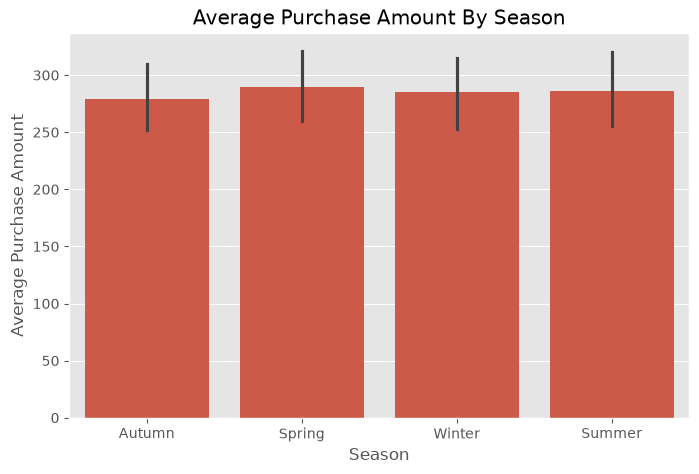

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Amount")

plt.title("Average Purchase Amount By Season")
plt.xlabel("Season")
plt.ylabel("Average Purchase Amount")

plt.savefig("../Images/Average_Purchase_Season.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Observation**

- Average purchase amount remains relatively consistent across all seasons.
- Spring records the highest average purchase amount, although the difference is small.
- No season shows a substantial increase or decrease in customer spending.
- Seasonal effects appear to have minimal impact on average purchase value.

### Correlation Heatmap

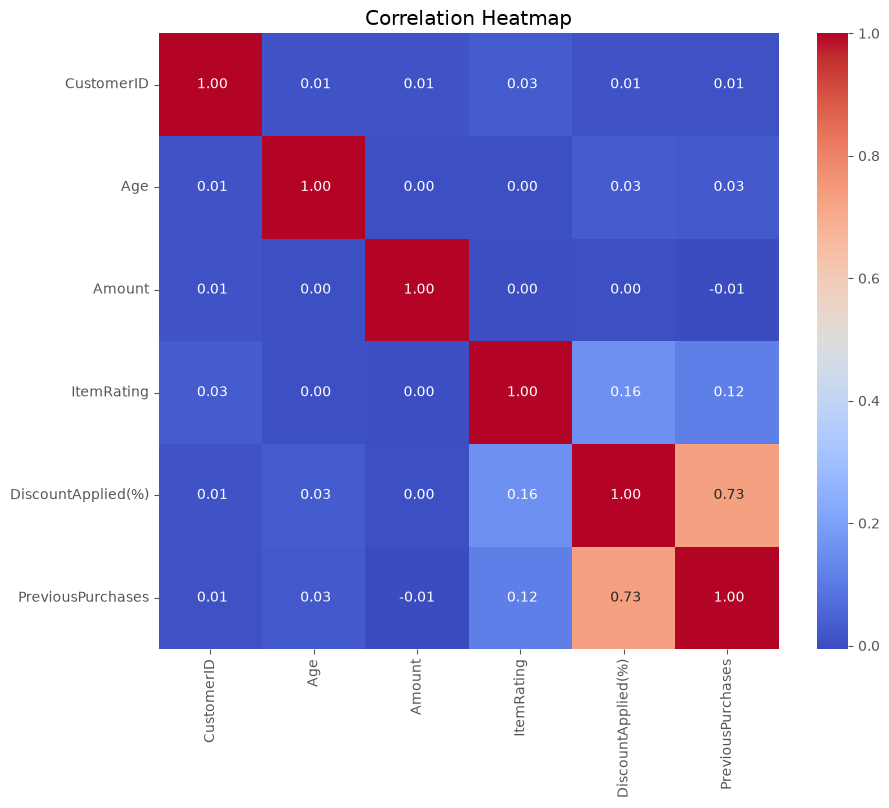

In [26]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),annot=True, cmap="coolwarm",fmt=" .2f")

plt.title("Correlation Heatmap")

plt.savefig("../Images/Correlation_heatmap.png",
            dpi=400,
            bbox_inches="tight")

plt.show()

**Observation**

- Most numerical variables show very weak or no linear correlation with each other.
- A strong positive correlation (0.73) exists between Discount Applied (%) and Previous Purchases, suggesting frequent customers tend to  receive higher discounts.
- Item Rating has a weak positive correlation with both Discount Applied (0.16) and Previous Purchases (0.12).
- Age and Purchase Amount show almost no correlation with the other numerical variables.
- CustomerID is an identifier and does not have any meaningful relationship with business variables.

### Purchase Amount By Gender

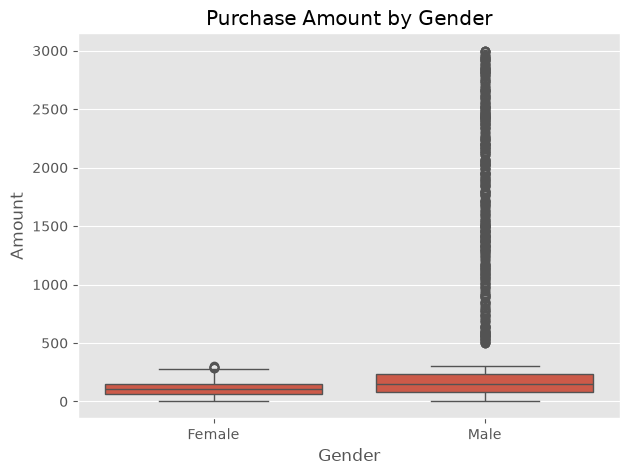

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Amount"
)
plt.title("Purchase Amount by Gender")

plt.savefig("../Images/purchase_by_Gender.png",
            dpi=400,
            bbox_inches="tight")

plt.show()

**Observation**

- Male customers have a higher median purchase amount than female customers.
- The purchase amount for male customers shows greater variability, indicating a wider spending range.
- Several high-value purchase outliers are present, particularly among male customers.
- Female customers generally make lower and more consistent purchase amounts.

## Conclusion

### Key Findings

- The dataset contains 5,000 customer purchase records with no missing values, making it suitable for analysis.
- Customer ages are evenly distributed between 20 and 70 years, indicating a diverse customer base.
- The number of male and female customers is nearly equal, suggesting balanced customer representation.
- Footwear and Sports are the most frequently purchased product categories.
- Electronics have the highest average purchase amount, contributing significantly to high-value sales.
- Laptops, Mobile Phones, Headphones, and Smart Watches generate the highest total revenue among all products.
- Purchase amounts remain relatively consistent across all seasons, indicating stable customer spending throughout the year.

---

## Business Recommendations

1. **Focus on high-performing products**
   - Increase inventory and marketing efforts for products such as Laptops, Mobile Phones, Headphones, and Smart Watches, as they generate the highest revenue.

2. **Strengthen customer loyalty programs**
   - Since repeat customers receive higher discounts, introduce loyalty rewards and personalized offers to encourage customer retention.

3. **Optimize product category strategy**
   - Continue investing in high-demand categories like Footwear and Sports while developing promotional campaigns to improve sales in lower-performing categories such as Home and Groceries.

4. **Expand premium product marketing**
   - Electronics have the highest average purchase value, making them suitable for premium promotions, bundle offers, and extended warranty programs.

---